# Ficheiro 2 - Morbilidade e Mortalidade Hospitalar

# ESTAÇÃO 3 — Guardar numa base de dados e consultar com SQL

O objetivo é guardar os dados de forma estruturada numa base de dados e realizar consultas SQL para explorar a informação.


## Análise da Demora Média por Diagnóstico e Faixa Etária

Como responsável clínico, quero ver a demora média por diagnóstico e faixa etária, para perceber que perfil de doente ocupa mais dias de internamento.

In [2]:
import sqlite3
import pandas as pd

df = pd.read_csv("../data/processed/morbilidade_mortalidade_tratado.csv", sep=",", encoding="utf-8-sig")


# Liga (ou cria) a base de dados SQLite
con = sqlite3.connect("../data/processed/morbilidade-hospital.db")

# df.to_sql escreve o DataFrame como uma TABELA dentro da base de dados.
# if_exists='replace' substitui a tabela se já existir; index=False não guarda o nº da linha.

df.to_sql("morbilidade", con, if_exists="replace", index=False)


q_diag = """
SELECT 
    descricao_diagnostico_principal,
    ROUND(SUM(dias_internamentos) * 1.0 / SUM(internamentos), 2) AS demora_media
FROM morbilidade
WHERE internamentos > 0
GROUP BY 
    descricao_diagnostico_principal
ORDER BY demora_media DESC;
"""
print("Demora média por diagnóstico:")
display(pd.read_sql(q_diag, con))



q = """

SELECT 

    faixa_etaria,        
    ROUND(SUM(dias_internamentos) / SUM(internamentos), 2) AS demora_media
FROM morbilidade
WHERE internamentos > 0 
GROUP BY faixa_etaria
ORDER BY demora_media DESC;
"""
print(" ")
print("Demora média por faixa etária:")
display(pd.read_sql(q, con))

Demora média por diagnóstico:


,descricao_diagnostico_principal,demora_media
0,"Transtornos mentais, comportamentais e de neur...",23.54
1,Algumas doenças infecciosas e parasitárias,13.09
2,Códigos para fins especiais,12.39
3,"Lesões, envenenamento e algumas outras consequ...",11.75
4,Doenças do sistema nervoso,11.38
5,Doenças da pele e do tecido subcutâneo,10.57
6,Doenças do aparelho circulatório,10.09
7,Doenças do sangue e dos órgãos hematopoéticos ...,9.84
8,Doenças do aparelho respiratório,9.11
9,Neoplasias,8.80


 
Demora média por faixa etária:


,faixa_etaria,demora_media
0,[65-120[,10.0
1,[45-65[,8.0
2,[25-45[,5.0
3,[15-25[,5.0
4,[5-15[,4.0
5,[1-5[,4.0
6,[0-1[,4.0


## Conclusão

A análise da demora média por diagnóstico revela que os internamentos mais prolongados estão associados principalmente a transtornos mentais, comportamentais e de neurodesenvolvimento, com uma média de 23 dias por internamento. Seguem-se as doenças infeciosas e parasitárias e códigos para fins especiais, ambos com valores superiores a 12 dias. Estes resultados sugerem que determinadas áreas clínicas apresentam maior complexidade ou necessidade de acompanhamento prolongado, refletindo-se em maiores períodos de hospitalização.


sexo
I    10.380952
M     8.966288
F     7.817760
Name: demora_media, dtype: float64


<Axes: title={'center': 'Demora média por sexo'}, xlabel='Sexo', ylabel='Demora média (dias)'>

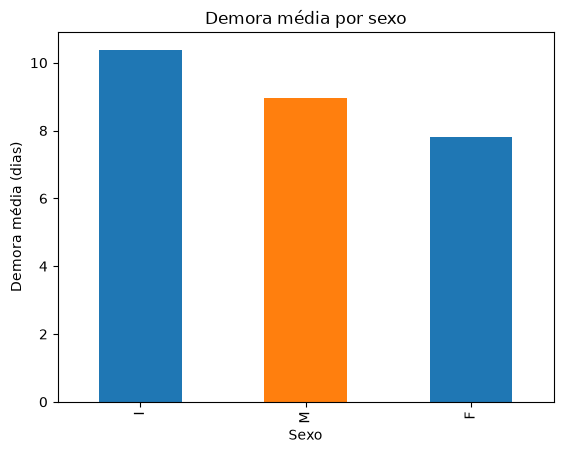

In [8]:
demora_sexo = df.groupby("sexo")["demora_media"].mean().sort_values(ascending=False)
print(demora_sexo)
demora_sexo.plot(kind="bar", title="Demora média por sexo", xlabel="Sexo", ylabel="Demora média (dias)", color=["#1f77b4", "#ff7f0e"])
